# Load Required Libraries
Import necessary libraries such as pandas, numpy, scikit-learn modules, and joblib for saving the model.

In [1]:
# Imports
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.utils import class_weight
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import tensorflow as tf
from tensorflow.keras import layers, models,regularizers

sns.set()

2026-03-24 06:04:58.004628: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774332298.373014      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774332298.474716      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774332299.357889      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774332299.357936      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774332299.357938      24 computation_placer.cc:177] computation placer alr

# Load Dataset
Load the dataset from the train.csv and test.csv files using pandas.

In [2]:
# Load Dataset
train_data = pd.read_csv("/kaggle/input/competitions/santander-customer-transaction-prediction/train.csv")
test_data = pd.read_csv("/kaggle/input/competitions/santander-customer-transaction-prediction/test.csv")

print("Train Data Shape:", train_data.shape)
print("Test Data Shape:", test_data.shape)

Train Data Shape: (200000, 202)
Test Data Shape: (200000, 201)


# Split Dataset into Train, Validation, and Test Sets
Split the train.csv dataset into an 80-20 train-validation split using train_test_split from scikit-learn.

In [3]:
# Split Dataset into Train, Validation, and Test Sets
# Drop non-feature ID_code before splitting
X = train_data.drop(columns=['target', 'ID_code'])
y = train_data['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Set Shape:", X_train.shape)
print("Validation Set Shape:", X_val.shape)

Training Set Shape: (160000, 200)
Validation Set Shape: (40000, 200)


# Normalize the Dataset
Normalize the features using StandardScaler from scikit-learn for both training and validation sets.

In [4]:
# Normalize the Dataset
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Feature normalization complete.")

Feature normalization complete.


# Logistic Regression Model
Train a logistic regression model using the training set with scikit-learn's LogisticRegression.

Model training complete.
Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     35903
           1       0.70      0.27      0.39      4097

    accuracy                           0.91     40000
   macro avg       0.81      0.63      0.67     40000
weighted avg       0.90      0.91      0.90     40000

ROC AUC (Validation Set): 0.8597
Confusion Matrix (Validation Set):
[[35420   483]
 [ 2993  1104]]


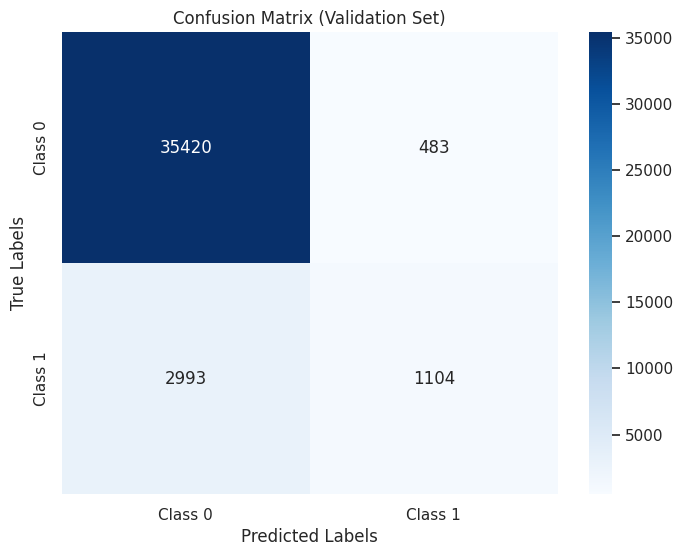

In [5]:
# Train Logistic Regression Model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

print("Model training complete.")
val_predictions = model.predict(X_val_scaled)

# ROC-AUC
if hasattr(model, 'predict_proba'):
    val_scores = model.predict_proba(X_val_scaled)[:, 1]
else:
    val_scores = model.decision_function(X_val_scaled)

val_auc = roc_auc_score(y_val, val_scores)

print("Classification Report (Validation Set):")
print(classification_report(y_val, val_predictions))
print(f"ROC AUC (Validation Set): {val_auc:.4f}")

print("Confusion Matrix (Validation Set):")
conf_matrix = confusion_matrix(y_val, val_predictions)
print(conf_matrix)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix (Validation Set)')
plt.show()

# Random Forest Classifier
Train and evaluate a Random Forest classifier on the normalized training/validation sets.

Random Forest Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     35903
           1       0.00      0.00      0.00      4097

    accuracy                           0.90     40000
   macro avg       0.45      0.50      0.47     40000
weighted avg       0.81      0.90      0.85     40000

Random Forest ROC AUC (Validation Set): 0.7796
Random Forest Confusion Matrix (Validation Set):
[[35903     0]
 [ 4097     0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


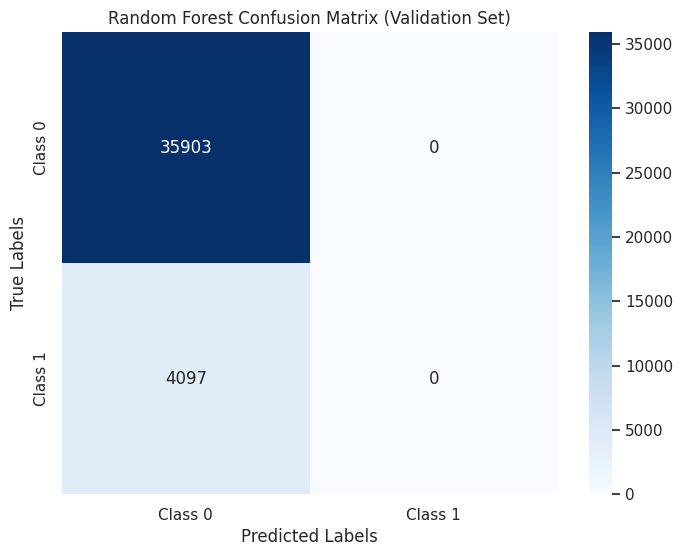

In [6]:
# Train and evaluate Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)

rf_val_pred = rf_model.predict(X_val_scaled)

# ROC-AUC
rf_scores = rf_model.predict_proba(X_val_scaled)[:, 1]
rf_auc = roc_auc_score(y_val, rf_scores)

print("Random Forest Classification Report (Validation Set):")
print(classification_report(y_val, rf_val_pred))
print(f"Random Forest ROC AUC (Validation Set): {rf_auc:.4f}")

print("Random Forest Confusion Matrix (Validation Set):")
conf_matrix_rf = confusion_matrix(y_val, rf_val_pred)
print(conf_matrix_rf)

# Plot confusion matrix for Random Forest
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Random Forest Confusion Matrix (Validation Set)')
plt.show()

# XGBoost Classifier
Train and evaluate an XGBoost classifier on the normalized training/validation sets.

XGBoost Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     35903
           1       0.67      0.26      0.37      4097

    accuracy                           0.91     40000
   macro avg       0.80      0.62      0.66     40000
weighted avg       0.90      0.91      0.89     40000

XGBoost ROC AUC (Validation Set): 0.8574
XGBoost Confusion Matrix (Validation Set):
[[35394   509]
 [ 3048  1049]]


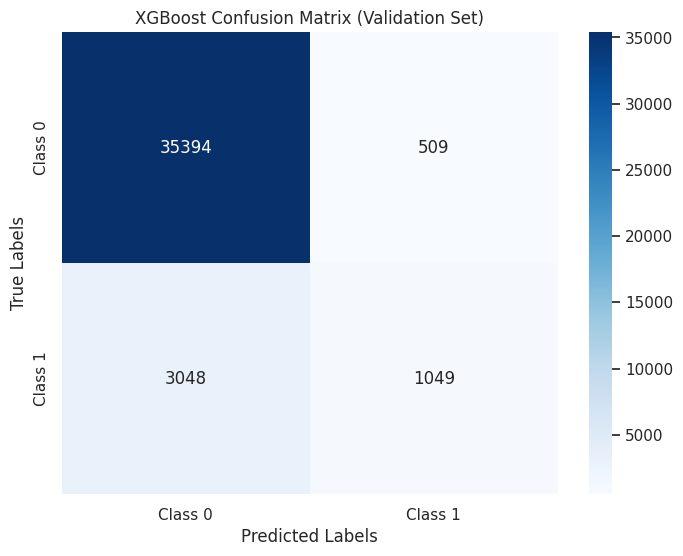

In [7]:
# Train and evaluate XGBoost classifier
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_model.fit(X_train_scaled, y_train)

xgb_val_pred = xgb_model.predict(X_val_scaled)

# ROC-AUC
xgb_scores = xgb_model.predict_proba(X_val_scaled)[:, 1]
xgb_auc = roc_auc_score(y_val, xgb_scores)

print("XGBoost Classification Report (Validation Set):")
print(classification_report(y_val, xgb_val_pred))
print(f"XGBoost ROC AUC (Validation Set): {xgb_auc:.4f}")

print("XGBoost Confusion Matrix (Validation Set):")
conf_matrix_xgb = confusion_matrix(y_val, xgb_val_pred)
print(conf_matrix_xgb)

# Plot confusion matrix for XGBoost
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('XGBoost Confusion Matrix (Validation Set)')
plt.show()

# LightGBM Classifier
Train and evaluate a LightGBM classifier on the normalized training/validation sets.

[LightGBM] [Info] Number of positive: 16001, number of negative: 143999
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.184798 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 51000
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 200
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.97      0.82      0.88     35903
           1       0.32      0.75      0.45      4097

    accuracy                           0.81     40000
   macro avg       0.64      0.78      0.67     40000
weighted avg       0.90      0.81      0.84     40000

LightGBM ROC AUC (Validation Set): 0.8667
LightGBM Confusion Matrix (Validation Set):
[[29296  6607]
 [ 1012  3085]]


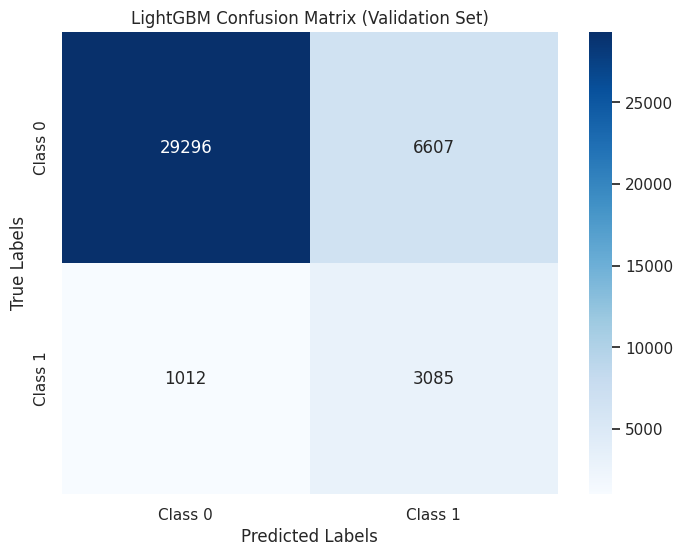

In [8]:
# Train and evaluate LightGBM classifier
lgb_model = LGBMClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
lgb_model.fit(X_train_scaled, y_train)

lgb_val_pred = lgb_model.predict(X_val_scaled)

# ROC-AUC
lgb_scores = lgb_model.predict_proba(X_val_scaled)[:, 1]
lgb_auc = roc_auc_score(y_val, lgb_scores)

print("LightGBM Classification Report (Validation Set):")
print(classification_report(y_val, lgb_val_pred))
print(f"LightGBM ROC AUC (Validation Set): {lgb_auc:.4f}")

print("LightGBM Confusion Matrix (Validation Set):")
conf_matrix_lgb = confusion_matrix(y_val, lgb_val_pred)
print(conf_matrix_lgb)

# Plot confusion matrix for LightGBM
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_lgb, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('LightGBM Confusion Matrix (Validation Set)')
plt.show()

# TensorFlow Neural Network (Keras)
Train and evaluate a TensorFlow Keras neural network classifier on the normalized training and validation sets.

I0000 00:00:1774332573.823154      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774332573.829001      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/200


I0000 00:00:1774332578.509156     100 service.cc:152] XLA service 0x7fd6dc030790 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774332578.509207     100 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774332578.509211     100 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774332579.123942     100 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774332582.664959     100 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


157/157 - 11s - 73ms/step - accuracy: 0.7739 - loss: 1.0321 - val_accuracy: 0.6167 - val_loss: 0.9515 - learning_rate: 5.0000e-04
Epoch 2/200
157/157 - 1s - 4ms/step - accuracy: 0.7082 - loss: 0.8438 - val_accuracy: 0.6249 - val_loss: 0.9344 - learning_rate: 5.0000e-04
Epoch 3/200
157/157 - 1s - 4ms/step - accuracy: 0.7286 - loss: 0.7728 - val_accuracy: 0.6742 - val_loss: 0.8336 - learning_rate: 5.0000e-04
Epoch 4/200
157/157 - 1s - 4ms/step - accuracy: 0.7500 - loss: 0.7187 - val_accuracy: 0.7165 - val_loss: 0.7406 - learning_rate: 5.0000e-04
Epoch 5/200
157/157 - 1s - 4ms/step - accuracy: 0.7606 - loss: 0.6762 - val_accuracy: 0.7399 - val_loss: 0.6748 - learning_rate: 5.0000e-04
Epoch 6/200
157/157 - 1s - 4ms/step - accuracy: 0.7654 - loss: 0.6379 - val_accuracy: 0.7594 - val_loss: 0.6152 - learning_rate: 5.0000e-04
Epoch 7/200
157/157 - 1s - 4ms/step - accuracy: 0.7679 - loss: 0.6093 - val_accuracy: 0.7749 - val_loss: 0.5719 - learning_rate: 5.0000e-04
Epoch 8/200
157/157 - 1s - 4ms

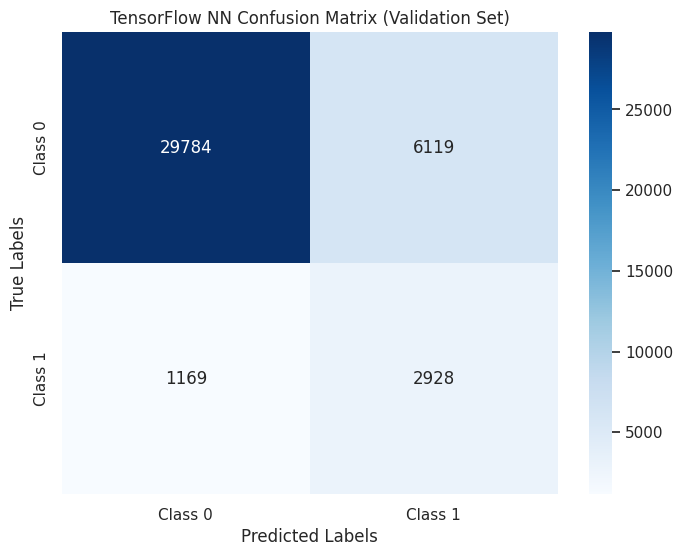

In [9]:
tf.random.set_seed(42)

# Compute class weights to handle class imbalance natively
cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(cw))

# --- UPDATED ARCHITECTURE ---
nn_model = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    
    # Layer 1: Narrower width + L2 Regularization + Higher Dropout
    layers.Dense(256, kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    # Layer 2: Compressing the representation
    layers.Dense(64, kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    # Layer 3: Bottleneck layer to force feature selection
    layers.Dense(16, kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),

    layers.Dense(1, activation='sigmoid')
])

# --- UPDATED OPTIMIZER ---
# Smaller initial learning rate for smoother convergence
opt = tf.keras.optimizers.Adam(learning_rate=5e-4)
nn_model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1)
]

# Train the model
history = nn_model.fit(X_train_scaled, y_train,validation_data=(X_val_scaled, y_val),epochs=200,batch_size=1024,callbacks=callbacks,class_weight=class_weights,verbose=2)

# Predict on validation set (probabilities for ROC-AUC)
probs_nn = nn_model.predict(X_val_scaled, batch_size=4096).ravel()

# Predict discrete classes for confusion matrix/report
nn_val_pred = (probs_nn >= 0.5).astype(int)

# Calculate mandatory ROC-AUC score
nn_auc_keras = roc_auc_score(y_val, probs_nn)

print("\n--- Neural Network (Keras) Validation Results ---")
print(f"ROC-AUC Score: {nn_auc_keras:.5f}\n")

print("Classification Report:")
print(classification_report(y_val, nn_val_pred))

print("Confusion Matrix:")
conf_matrix_tf = confusion_matrix(y_val, nn_val_pred)
print(conf_matrix_tf)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_tf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('TensorFlow NN Confusion Matrix (Validation Set)')
plt.show()

# K-Nearest Neighbors (KNN) Classifier
Train and evaluate a KNN classifier on the normalized training/validation sets.

KNN Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     35903
           1       0.00      0.00      0.00      4097

    accuracy                           0.90     40000
   macro avg       0.45      0.50      0.47     40000
weighted avg       0.81      0.90      0.85     40000

KNN ROC AUC (Validation Set): 0.7298
KNN Confusion Matrix (Validation Set):
[[35903     0]
 [ 4097     0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


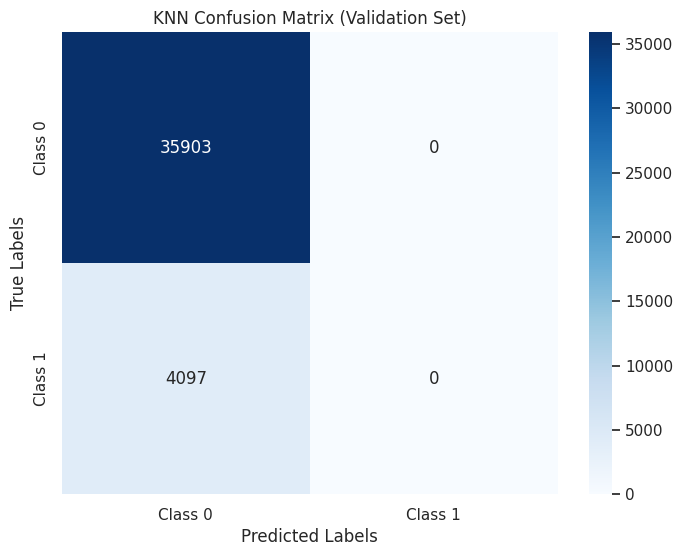

In [10]:
# Train and evaluate K-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=100, n_jobs=-1)
knn.fit(X_train_scaled, y_train)

knn_val_pred = knn.predict(X_val_scaled)

# ROC-AUC for KNN
if hasattr(knn, 'predict_proba'):
    knn_scores = knn.predict_proba(X_val_scaled)[:, 1]
else:
    knn_scores = knn.predict(X_val_scaled)
knn_auc = roc_auc_score(y_val, knn_scores)

print("KNN Classification Report (Validation Set):")
print(classification_report(y_val, knn_val_pred))
print(f"KNN ROC AUC (Validation Set): {knn_auc:.4f}")

print("KNN Confusion Matrix (Validation Set):")
conf_matrix_knn = confusion_matrix(y_val, knn_val_pred)
print(conf_matrix_knn)

# Plot confusion matrix for KNN
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('KNN Confusion Matrix (Validation Set)')
plt.show()

# Save models, scaler, and dataset splits

In [11]:
import os
os.makedirs('artifacts', exist_ok=True)

# Save scaler
joblib.dump(scaler, 'artifacts/scaler.joblib')
print('Saved scaler: artifacts/scaler.joblib')

# Save models if present (sklearn-compatible via joblib)
models = {
    'logistic_regression': globals().get('model'),
    'random_forest': globals().get('rf_model'),
    'xgboost': globals().get('xgb_model'),
    'lightgbm': globals().get('lgb_model'),
    'knn': globals().get('knn'),
}
for name, m in models.items():
    if m is not None:
        try:
            joblib.dump(m, f'artifacts/{name}.pkl')
            print(f'Saved {name} as artifacts/{name}.pkl')
        except Exception as e:
            print(f'Failed to save {name} with joblib: {e}')

# Save TensorFlow Keras model separately if present (native .keras format)
keras_model = globals().get('nn_model')
if keras_model is not None:
    try:
        keras_model.save('artifacts/nn_keras.keras')
        print('Saved Keras model: artifacts/nn_keras.keras')
    except Exception as e:
        print('Failed to save Keras model:', e)

# Save dataset splits (original, not scaled)
X_train.to_csv('artifacts/X_train.csv', index=False)
X_val.to_csv('artifacts/X_val.csv', index=False)
y_train.to_csv('artifacts/y_train.csv', index=False)
y_val.to_csv('artifacts/y_val.csv', index=False)
print('Saved dataset splits to artifacts/')

# Save a brief metadata file describing the split
with open('artifacts/split_info.txt', 'w') as f:
    f.write(f'Train shape: {X_train.shape}\n')
    f.write(f'Validation shape: {X_val.shape}\n')
    f.write('Split method: train_test_split(test_size=0.2, random_state=42)\n')

print('Artifacts saved in artifacts/ folder')

Saved scaler: artifacts/scaler.joblib
Saved logistic_regression as artifacts/logistic_regression.pkl
Saved random_forest as artifacts/random_forest.pkl
Saved xgboost as artifacts/xgboost.pkl
Saved lightgbm as artifacts/lightgbm.pkl
Saved knn as artifacts/knn.pkl
Saved Keras model: artifacts/nn_keras.keras
Saved dataset splits to artifacts/
Artifacts saved in artifacts/ folder
